In [10]:
import random 
import warnings 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter,sosfiltfilt,savgol_filter,find_peaks
warnings.filterwarnings("ignore")
SEED=42
random.seed(SEED)
np.random.seed(SEED)
sns.set_style("whitegrid")

In [11]:
FS=125 
WINDOW_SECONDS=8 
WINDOW_SIZE=WINDOW_SECONDS*FS
STEP_SECONDS=4 
STEP_SIZE=STEP_SECONDS*FS
PATIENT_IDS=[1,2,3,4,5]



In [12]:
FS = 125                 # PPG sampling frequency
WINDOW_SECONDS = 8       # Each PPG sample/window is 8 seconds
WINDOW_SIZE = FS * WINDOW_SECONDS
STEP_SECONDS = 4
STEP_SIZE = FS * STEP_SECONDS

# Small classroom demo: first 5 patient records
PATIENT_IDS = [1, 2, 3, 4, 5]

BASE_URL = (
    "https://physionet.org/files/bidmc/1.0.0/bidmc_csv"
)

print("Sampling frequency:", FS, "Hz")
print("Window size:", WINDOW_SECONDS, "seconds")
print("Samples per window:", WINDOW_SIZE)

Sampling frequency: 125 Hz
Window size: 8 seconds
Samples per window: 1000


In [13]:
def load_patient(patient_id):
    """
    Load a single patient record from the BIDMC dataset.
    """
    signal_url = f"{BASE_URL}/bidmc_{patient_id:02d}_Signals.csv"
    numeric_url = f"{BASE_URL}/bidmc_{patient_id:02d}_Numerics.csv"
    signals = pd.read_csv(signal_url)
    numerics = pd.read_csv(numeric_url)
    signals.columns=signals.columns.str.strip()
    numerics.columns=numerics.columns.str.strip()
    return signals, numerics
all_patient_data=[]
for patient_id in PATIENT_IDS:
    signals, numerics = load_patient(patient_id)
    all_patient_data.append({
        "patient_id": patient_id,
        "signals": signals,
        "numerics": numerics,
    })
    print(f"Loaded patient {patient_id}: {signals.shape[0]} samples, {numerics.shape[0]} numeric records")

Loaded patient 1: 60001 samples, 481 numeric records
Loaded patient 2: 60001 samples, 481 numeric records
Loaded patient 3: 60001 samples, 481 numeric records
Loaded patient 4: 60001 samples, 481 numeric records
Loaded patient 5: 60001 samples, 481 numeric records


In [14]:
example_signals=all_patient_data[1]['signals']
example_numerics=all_patient_data[1]['numerics']

print(example_signals.columns.tolist())
print(example_numerics.columns.tolist())
print(example_signals.head())
print(example_numerics.head())

['Time [s]', 'II', 'PLETH', 'RESP', 'V', 'AVR']
['Time [s]', 'HR', 'PULSE', 'RESP', 'SpO2']
   Time [s]       II    PLETH     RESP        V      AVR
0     0.000  0.14453  0.63636  0.04059  0.83529  0.74414
1     0.008  0.15625  0.65689  0.04059  0.83529  0.74023
2     0.016  0.15625  0.67351  0.04059  0.84118  0.74023
3     0.024  0.16016  0.68817  0.04059  0.84510  0.73438
4     0.032  0.16016  0.69990  0.04059  0.84510  0.73438
   Time [s]  HR  PULSE  RESP  SpO2
0         0  93     92    16   100
1         1  93     93    16   100
2         2  93     93    16   100
3         3  94     94    16   100
4         4  94     94    16   100


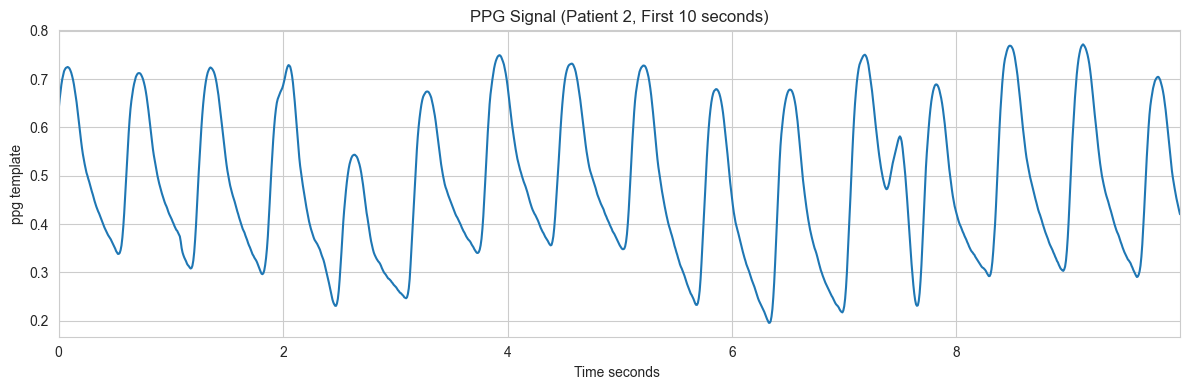

In [16]:
duration=10 
number_of_samples=duration*FS
time=example_signals['Time [s]'][:number_of_samples]
ppg=example_signals['PLETH'][:number_of_samples]

plt.figure(figsize=(12,4))
plt.plot(time,ppg)
plt.title("PPG Signal (Patient 2, First 10 seconds)")
plt.xlabel('Time seconds ')
plt.ylabel('ppg template')
plt.xlim(time.iloc[0],time.iloc[-1])
plt.tight_layout()
plt.show()

In [18]:
ACTIONS={
    0:"Raw Signal",
    1:"Moving Average",
    2:"Savitzky-Golay",
    3:"Butterworth Bandpass"
}

N_ACTIONS=len(ACTIONS)
for action_id,action_name in ACTIONS.items():
    print(f"{action_id}: {action_name}")

0: Raw Signal
1: Moving Average
2: Savitzky-Golay
3: Butterworth Bandpass


In [19]:
def moving_average_filter(signal, window=7):
    kernel = np.ones(window) / window

    filtered = np.convolve(
        signal,
        kernel,
        mode="same"
    )

    return filtered


def savgol_ppg_filter(signal):
    """
    Smooth the signal while preserving the shape of PPG peaks.
    """
    return savgol_filter(
        signal,
        window_length=21,
        polyorder=3
    )


def butterworth_filter(signal, fs=125):
    """
    PPG heart-rate frequency range:
    approximately 0.5 to 5 Hz.
    """

    sos = butter(
        N=4,
        Wn=[0.5, 5.0],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    return sosfiltfilt(sos, signal)


def apply_action(signal, action):
    """
    Apply the filter selected by the RL agent.
    """

    if action == 0:
        return signal.copy()

    elif action == 1:
        return moving_average_filter(signal)

    elif action == 2:
        return savgol_ppg_filter(signal)

    elif action == 3:
        return butterworth_filter(signal, FS)

    else:
        raise ValueError("Invalid action")

In [20]:
def estimate_heart_rate(signal,fs=125):
    signal=np.array(signal,dtype=float)
    normalized_signal=(signal-np.mean(signal))/(np.std(signal)+1e-8)
    
    minimum_distance=int(0.5*fs)
    peaks,_=find_peaks(normalized_signal,distance=minimum_distance,prominence=0.35)
    if len(peaks)<2:
        return np.nan,peaks 
    
    peak_intervals=np.diff(peaks)/fs
    median_interval=np.median(peak_intervals)
    estimated_hr=60/median_interval
    
    
    if  estimated_hr <35 or estimated_hr > 220 : 
        return np.nan ,peaks 
    
    return estimated_hr,peaks 
    

In [21]:
def calculate_noise_score(signal):
    smooth_signal=savgol_ppg_filter(signal,window_length=31,polyorder=3)
    high_frequency_part=signal-smooth_signal
    score=(np.std(high_frequency_part)/np.std(signal)+1e-8)